In [70]:
import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt


In [71]:

import pandas as pd

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)



In [72]:
df=pd.read_csv("/content/gurgaon_properties_cleaned_v2.csv")

In [73]:
df.select_dtypes(include='number').columns

Index(['price', 'price_per_sqft', 'area', 'bedRoom', 'bathroom', 'floorNum',
       'super_built_up_area', 'built_up_area', 'carpet_area', 'study room',
       'servant room', 'store room', 'pooja room', 'others', 'furnishing_type',
       'luxury_score'],
      dtype='object')

In [74]:
cols=['Unnamed: 0', 'price', 'price_per_sqft', 'area', 'bedRoom', 'bathroom',
       'floorNum', 'Furnish_type', 'super_built', 'buld_area', 'carpet_area',
       'others', 'pooja room', 'servant room', 'store room', 'study room',
       'rating']

In [75]:
def outlier_detection(x):
  print( sns.kdeplot(df[x]))
  plt.figure()
  print(  sns.boxplot(df[x],orient='h'))

  q1=df[x].quantile(0.25)
  q3=df[x].quantile(0.75)
  print(f"{q1}----{q3}")

  iqr=q3-q1
  lower_bound=q1-1.5*iqr
  upper_bound=q3+1.5*iqr
  return(df[(df[x]<lower_bound) | (df[x]>upper_bound)].sort_values(x,ascending=False))

Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)
0.94----2.7


,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
821,house,arjun marg/ sector- 26 phase- 1/ golf course road,sector 26,31.50,35000.0,9000.0,Plot area 1000(836.13 sq.m.),7,9,3+,3.0,North-East,Moderately Old,NaN,9000.00,NaN,1,1,1,1,0,2,74
2834,house,independent,sector 43,27.50,24366.0,11286.0,Plot area 1254(1048.5 sq.m.),6,7,3+,3.0,North-East,Relatively New,NaN,11286.00,NaN,1,1,0,1,1,1,42
2211,house,independent,sector 26,26.00,82540.0,3150.0,Plot area 402(336.12 sq.m.)Built Up area: 400 ...,16,16,3+,4.0,North-West,New Property,NaN,400.00,350.0,1,1,1,1,0,2,72
2488,house,dlf city plots,sector 26,26.00,57206.0,4545.0,Plot area 505(422.24 sq.m.),6,7,3+,2.0,North-East,New Property,NaN,4545.00,NaN,1,1,0,1,1,1,138
1686,house,suncity township,sector 54,25.00,31111.0,8036.0,Plot area 1000(836.13 sq.m.),4,4,3+,2.0,North,Moderately Old,NaN,1000.00,NaN,1,1,1,1,0,0,0
3046,house,emaar the palm springs,sector 54,24.00,600000.0,400.0,Plot area 400(37.16 sq.m.),5,5,2,1.0,North-East,Old Property,NaN,400.00,NaN,1,1,0,1,0,1,122
2765,house,independent,sector 26,23.00,25556.0,9000.0,Plot area 1000(836.13 sq.m.),4,4,3+,2.0,South-West,Relatively New,NaN,9000.00,NaN,1,1,1,1,0,1,145
2667,house,vipul tatvam villa,sector 48,22.00,26667.0,8250.0,Plot area 1000(836.13 sq.m.),5,6,3,3.0,NaN,Moderately Old,NaN,1000.00,NaN,0,1,0,0,0,0,54
2096,house,luxury dlf city floors,sector 26,20.00,48889.0,4091.0,Plot area 500(418.06 sq.m.),16,16,3+,4.0,NaN,New Property,NaN,500.00,NaN,0,1,0,0,0,1,31
874,house,dlf city plots,sector 26,20.00,44265.0,4518.0,Plot area 502(419.74 sq.m.),16,20,3+,4.0,North-East,New Property,NaN,4518.00,NaN,1,1,1,1,0,1,153


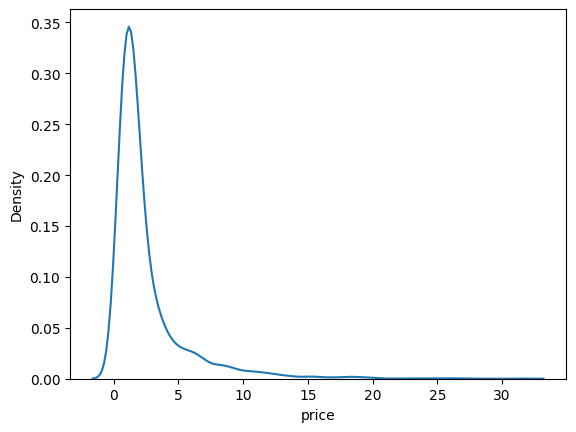

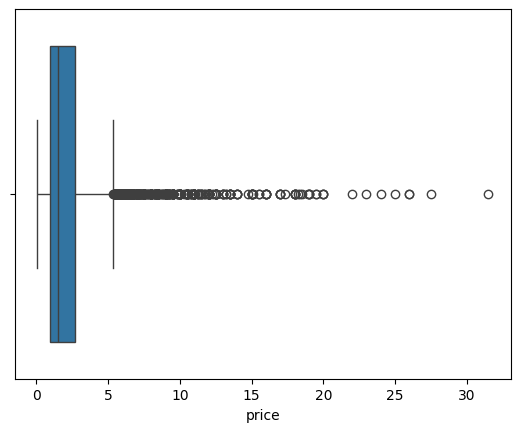

In [76]:
outlier_detection("price")

In [77]:
df["area"][df["area"]<1000]

,area
3,585.0
5,532.0
15,846.0
21,661.0
24,735.0
28,450.0
37,370.0
43,696.0
54,650.0
60,462.0


Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)
6808.0----13765.0


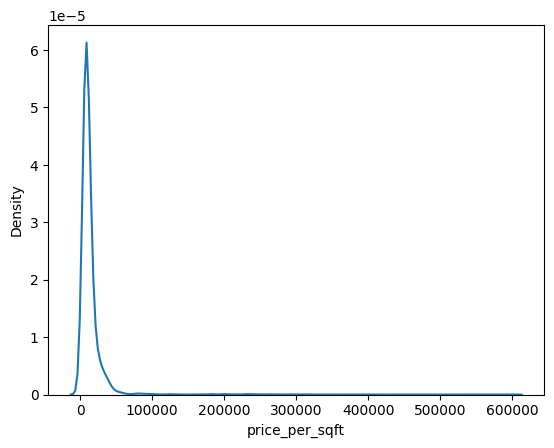

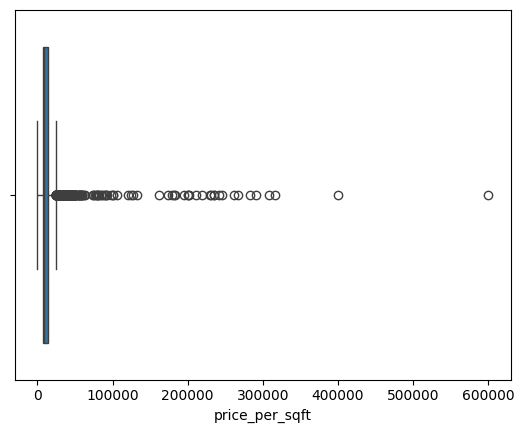

In [78]:
new_price=outlier_detection("price_per_sqft")

In [79]:
new_price.head(5)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
3046,house,emaar the palm springs,sector 54,24.00,600000.0,400.0,Plot area 400(37.16 sq.m.),5,5,2,1.0,North-East,Old Property,NaN,400.0,NaN,1,1,0,1,0,1,122
2850,house,dlf city plots phase 2,sector 25,10.00,400000.0,250.0,Plot area 250(23.23 sq.m.),12,12,3+,4.0,North,Relatively New,NaN,250.0,NaN,1,1,0,0,0,1,114
2461,house,independent,sector 12,6.00,315789.0,190.0,Plot area 190(17.65 sq.m.)Carpet area: 1600 sq...,9,6,2,2.0,North-East,Old Property,NaN,NaN,1600.0,0,0,0,0,0,0,0
2047,house,ansal,sector 43,1.85,308333.0,60.0,Plot area 60(5.57 sq.m.),8,8,3+,5.0,North-West,Relatively New,NaN,60.0,NaN,0,0,0,0,0,0,53
975,house,uppal southend,sector 49,6.75,290948.0,232.0,Plot area 232(21.55 sq.m.),12,12,3+,NaN,West,Moderately Old,NaN,232.0,NaN,1,1,0,1,1,1,49


In [80]:
new_price["area"]=new_price["area"].apply(lambda x :x*9 if x<1000 else x)

In [81]:
df.loc[new_price["area"].index]["area"]=new_price["area"]

In [82]:
df["price_per_sqft"]=round(df["price"]*10000000/df["area"])

In [83]:
df.loc[new_price["area"].index]["price_per_sqft"].describe()

,price_per_sqft
count,367.000000
mean,52115.212534
std,60744.160011
min,24202.000000
25%,27778.000000
50%,33333.000000
75%,41789.500000
max,600000.000000


In [84]:
df.drop(df[df["price_per_sqft"]>=50000].index,inplace=True)

<Axes: xlabel='price_per_sqft'>

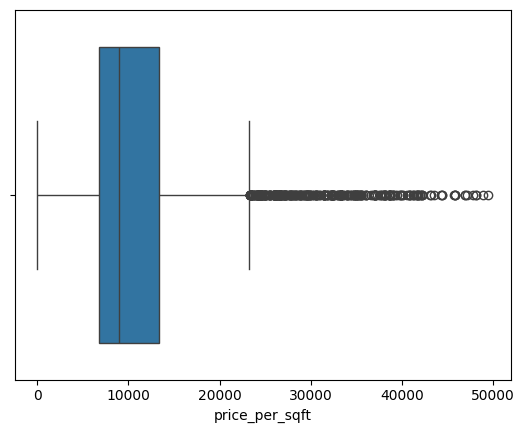

In [85]:
sns.boxplot(df["price_per_sqft"],orient="h")

In [86]:
df.shape

(3736, 23)

<Axes: xlabel='area', ylabel='Density'>

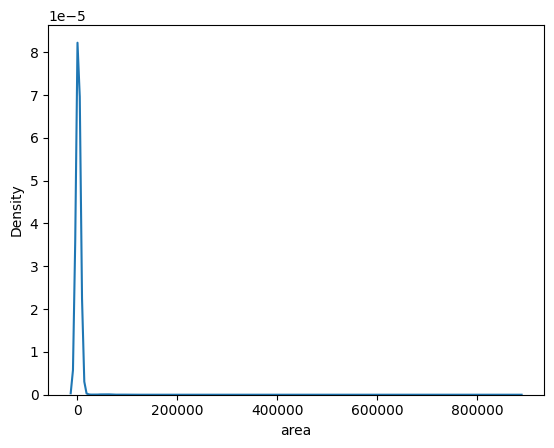

In [87]:
sns.kdeplot(df["area"])

<Axes: xlabel='area'>

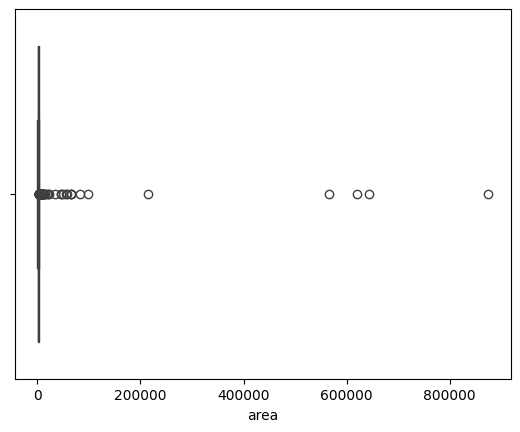

In [88]:
sns.boxplot(df["area"],orient="h")

In [89]:
df["area"].describe()

,area
count,3718.000000
mean,2885.407477
std,22985.500660
min,72.000000
25%,1250.000000
50%,1735.500000
75%,2300.000000
max,875000.000000


In [90]:
df=df[df["area"]<=100000]

In [91]:
df.shape

(3713, 23)

Axes(0.125,0.11;0.775x0.77)


,area
count,3713.000000
mean,2102.855912
std,3577.236697
min,72.000000
25%,1250.000000
50%,1735.000000
75%,2298.000000
max,98978.000000


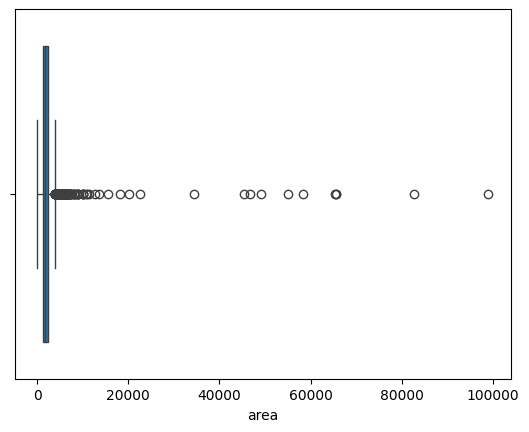

In [92]:
print(sns.boxplot(df["area"],orient="h"))
df["area"].describe()

In [93]:
df[df["area"]>10000].sort_values("area",ascending=False)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
818,house,independent,sector 26,18.40,1859.0,98978.0,Plot area 502(419.74 sq.m.)Carpet area: 11000 ...,6,8,3+,4.0,South,Relatively New,NaN,NaN,11000.00,0,1,1,1,0,1,60
48,house,ganpati heights apartment,sector 13,1.25,151.0,82781.0,Plot area 115(7692.86 sq.m.),10,6,2,3.0,South-East,Old Property,NaN,115.0,NaN,0,0,0,0,1,0,7
1123,flat,rof ananda,sector 95,0.38,58.0,65517.0,Carpet area: 64412 (5984.07 sq.m.),3,2,1,12.0,North,Relatively New,NaN,NaN,64412.00,0,0,0,0,0,0,51
1796,flat,rof ananda,sector 95,0.38,58.0,65517.0,Carpet area: 64529 (5994.94 sq.m.),2,2,2,10.0,East,New Property,NaN,NaN,64529.00,1,0,0,0,0,0,15
300,house,dlf city plot phase 4,sector 28,13.00,1992.0,65261.0,Carpet area: 7250 (6061.92 sq.m.),10,10,3+,1.0,NaN,Undefined,NaN,NaN,7250.00,0,0,0,0,0,0,0
2,flat,pyramid elite,sector 86,0.46,79.0,58228.0,Carpet area: 58141 (5401.48 sq.m.),2,2,1,0.0,NaN,Under Construction,NaN,NaN,58141.00,0,0,0,0,0,0,15
2356,flat,rof ananda,sector 95,0.33,60.0,55000.0,Carpet area: 54917 (5101.96 sq.m.),2,2,1,13.0,South-West,Relatively New,NaN,NaN,54917.00,0,0,0,0,0,0,37
115,flat,signature the serenas,sohna road,0.28,57.0,49123.0,Carpet area: 48811 (4534.69 sq.m.),1,1,2,1.0,North-West,Relatively New,NaN,NaN,48811.00,1,0,0,0,0,0,37
2666,house,independent,sector 25,7.30,1560.0,46795.0,Plot area 215(179.77 sq.m.)Built Up area: 5800...,9,9,2,3.0,North-West,Relatively New,NaN,5800.0,5200.00,0,1,1,0,0,1,109
3649,flat,ramsons kshitij,sector 95,0.24,53.0,45283.0,Carpet area: 45966 (4270.38 sq.m.),2,2,1,10.0,North-West,Relatively New,NaN,NaN,45966.00,0,0,0,0,1,0,33


In [94]:
df.loc[48,"area"]=115*9
df.loc[300,"area"]=7250
df.loc[2666,"area"]=5800
df.loc[1358,"area"]=2660
df.loc[3195,"area"]=2850
df.loc[2131,"area"]=1812
df.loc[3088,"area"]=2160
df.loc[34444,"area"]=1175




In [95]:
# df.drop(index=[818,1796,1123,2,2356,115,3649,2503,1471],inplace=True,axis=0)

In [96]:
df["bedRoom"].describe()

,bedRoom
count,3713.000000
mean,3.274441
std,1.740534
min,1.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,21.000000


In [97]:
# df[df["bedRoom"]==21]
# 3618

In [98]:
df=df[df["bedRoom"]<10]

In [99]:
df.shape

(3658, 23)

<Axes: xlabel='bedRoom', ylabel='Density'>

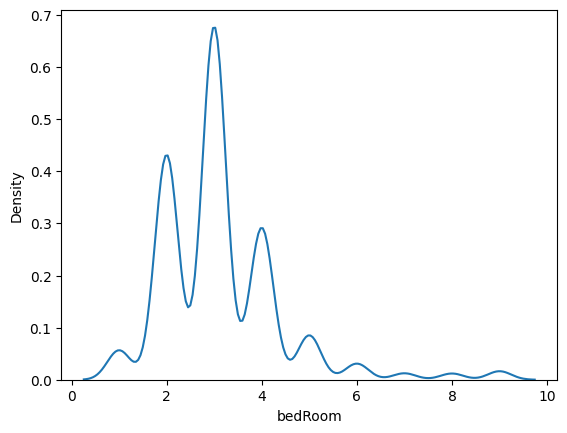

In [100]:
sns.kdeplot(df["bedRoom"])

<Axes: xlabel='bedRoom'>

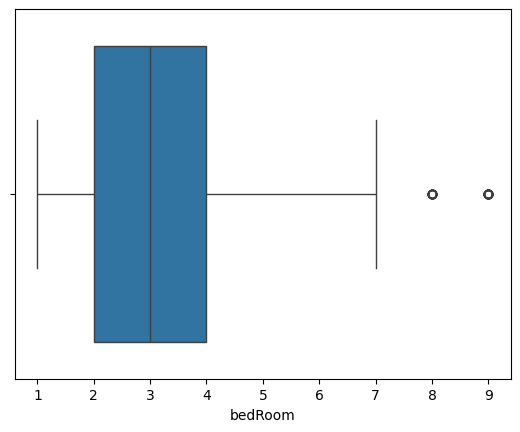

In [101]:
sns.boxplot(df["bedRoom"],orient="h")

In [102]:
df[df["bathroom"]>10].sort_values("bathroom",ascending=False)
# Genuine

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
3267,house,adani brahma samsara,sector 60,18.02,28200.0,6390.0,Built Up area: 6390 (593.65 sq.m.),9.0,12.0,3+,3.0,North-East,Relatively New,NaN,6390.0,NaN,0.0,1.0,0.0,0.0,0.0,1.0,146.0
2816,house,independent,sector 24,11.00,28902.0,3806.0,Plot area 3806.45(353.63 sq.m.)Built Up area: ...,8.0,11.0,3+,3.0,East,Old Property,NaN,5000.0,NaN,1.0,1.0,0.0,1.0,1.0,1.0,39.0


<Axes: xlabel='super_built_up_area', ylabel='Density'>

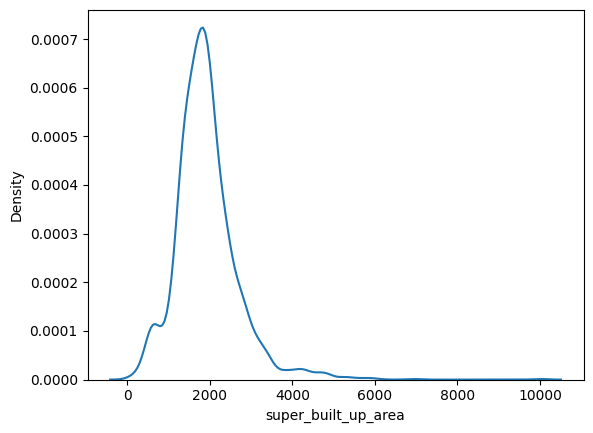

In [103]:
sns.kdeplot(df["super_built_up_area"])

<Axes: xlabel='super_built_up_area'>

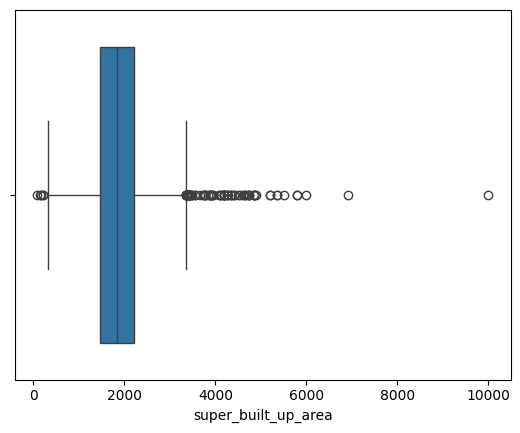

In [104]:
sns.boxplot(df["super_built_up_area"],orient="h")

In [105]:
df["super_built_up_area"].describe()

,super_built_up_area
count,1915.000000
mean,1921.658251
std,767.160169
min,89.000000
25%,1457.000000
50%,1828.000000
75%,2215.000000
max,10000.000000


In [106]:
df.drop(df[df["super_built_up_area"]<100].index,inplace=True)

In [107]:
df.shape

(3657, 23)

In [108]:
df["built_up_area"].describe()

,built_up_area
count,1599.000000
mean,1962.461144
std,1385.505349
min,14.000000
25%,1178.000000
50%,1670.000000
75%,2394.000000
max,13500.000000


In [109]:
df[df["built_up_area"]<100]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
988,flat,godrej air,sector 85,1.05,10606.0,990.0,Built Up area: 97 Carpet area: 92 sq.m.,2.0,2.0,1,15.0,East,Under Construction,NaN,97.0,92.0,0.0,0.0,0.0,0.0,0.0,0.0,45.0
1149,house,independent,sector 4,0.47,10609.0,443.0,Plot area 49(40.97 sq.m.)Built Up area: 50 sq....,2.0,2.0,1,2.0,East,New Property,NaN,50.0,48.0,1.0,0.0,0.0,0.0,0.0,1.0,73.0
1232,flat,godrej air,sector 85,1.05,10606.0,990.0,Built Up area: 97 Carpet area: 92 sq.m.,2.0,2.0,1,15.0,East,Under Construction,NaN,97.0,92.0,0.0,0.0,0.0,0.0,0.0,0.0,45.0
1429,house,sector 38 rwa,sector 38,1.40,23932.0,585.0,Plot area 65(54.35 sq.m.)Built Up area: 62 sq....,8.0,8.0,3,4.0,East,Moderately Old,NaN,62.0,60.0,0.0,0.0,0.0,0.0,1.0,1.0,40.0
1644,house,eros rosewood city,sector 49,1.60,31496.0,508.0,Plot area 60(50.17 sq.m.),4.0,4.0,3,4.0,East,New Property,NaN,60.0,NaN,0.0,0.0,0.0,0.0,0.0,1.0,27.0
1801,house,independent,sector 46,2.25,24510.0,918.0,Plot area 102(85.28 sq.m.)Built Up area: 90 sq...,4.0,3.0,3,3.0,North-East,Relatively New,NaN,90.0,85.0,1.0,0.0,0.0,0.0,0.0,1.0,35.0
2167,house,suncity township,sector 54,2.00,30960.0,646.0,Plot area 60Built Up area: 60 sq.m.Carpet area...,9.0,9.0,3,11.0,North,Relatively New,NaN,60.0,59.0,0.0,1.0,0.0,0.0,0.0,2.0,7.0
2190,house,independent,sohna road,0.07,2527.0,277.0,Plot area 33(27.59 sq.m.),1.0,1.0,0,1.0,NaN,Relatively New,NaN,33.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2221,house,independent,sector 4,0.55,6815.0,807.0,Built Up area: 75,2.0,1.0,1,1.0,NaN,Moderately Old,NaN,75.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2913,house,independent,sector 9,4.50,14286.0,3150.0,Plot area 14(354.1 sq.m.),9.0,9.0,3+,3.0,NaN,Relatively New,NaN,14.0,NaN,1.0,0.0,0.0,1.0,1.0,1.0,38.0


<Axes: xlabel='carpet_area', ylabel='Density'>

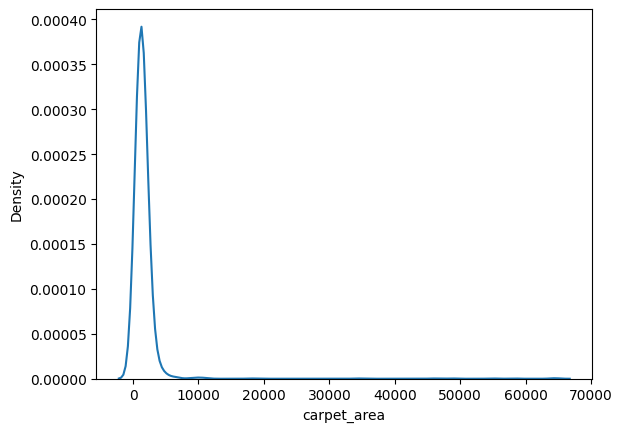

In [110]:
sns.kdeplot(df["carpet_area"])

In [111]:
df["carpet_area"].describe()

,carpet_area
count,1915.000000
mean,1618.978892
std,3339.368348
min,33.000000
25%,845.000000
50%,1300.000000
75%,1784.500000
max,64529.000000


In [112]:
df[df["carpet_area"]>10000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2,flat,pyramid elite,sector 86,0.46,79.0,58228.0,Carpet area: 58141 (5401.48 sq.m.),2.0,2.0,1,0.0,NaN,Under Construction,NaN,NaN,58141.0,0.0,0.0,0.0,0.0,0.0,0.0,15.0
115,flat,signature the serenas,sohna road,0.28,57.0,49123.0,Carpet area: 48811 (4534.69 sq.m.),1.0,1.0,2,1.0,North-West,Relatively New,NaN,NaN,48811.0,1.0,0.0,0.0,0.0,0.0,0.0,37.0
818,house,independent,sector 26,18.40,1859.0,98978.0,Plot area 502(419.74 sq.m.)Carpet area: 11000 ...,6.0,8.0,3+,4.0,South,Relatively New,NaN,NaN,11000.0,0.0,1.0,1.0,1.0,0.0,1.0,60.0
1123,flat,rof ananda,sector 95,0.38,58.0,65517.0,Carpet area: 64412 (5984.07 sq.m.),3.0,2.0,1,12.0,North,Relatively New,NaN,NaN,64412.0,0.0,0.0,0.0,0.0,0.0,0.0,51.0
1796,flat,rof ananda,sector 95,0.38,58.0,65517.0,Carpet area: 64529 (5994.94 sq.m.),2.0,2.0,2,10.0,East,New Property,NaN,NaN,64529.0,1.0,0.0,0.0,0.0,0.0,0.0,15.0
2131,flat,godrej air,sector 85,2.50,1379.0,1812.0,Carpet area: 18122 (1683.59 sq.m.),4.0,5.0,3+,16.0,North-East,Under Construction,NaN,NaN,18122.0,1.0,0.0,0.0,1.0,1.0,1.0,44.0
2342,flat,m3m golfestate,sector 65,13.20,12000.0,11000.0,Carpet area: 11000 (1021.93 sq.m.),4.0,4.0,3,13.0,North,Moderately Old,NaN,NaN,11000.0,0.0,1.0,0.0,0.0,0.0,0.0,60.0
2356,flat,rof ananda,sector 95,0.33,60.0,55000.0,Carpet area: 54917 (5101.96 sq.m.),2.0,2.0,1,13.0,South-West,Relatively New,NaN,NaN,54917.0,0.0,0.0,0.0,0.0,0.0,0.0,37.0
2503,flat,rof ananda,sector 95,0.21,61.0,34426.0,Carpet area: 34401 (3195.96 sq.m.),1.0,1.0,1,13.0,North,Relatively New,NaN,NaN,34401.0,0.0,0.0,0.0,0.0,0.0,0.0,68.0
3649,flat,ramsons kshitij,sector 95,0.24,53.0,45283.0,Carpet area: 45966 (4270.38 sq.m.),2.0,2.0,1,10.0,North-West,Relatively New,NaN,NaN,45966.0,0.0,0.0,0.0,0.0,1.0,0.0,33.0


In [113]:
df.loc[2131,"carpet_area"]=1812

In [114]:
df.sample(5)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
3792,flat,ss the leaf,sector 85,1.25,7180.0,1741.0,Carpet area: 1741 (161.74 sq.m.),2.0,2.0,2,16.0,North,Relatively New,NaN,NaN,1741.0,0.0,0.0,0.0,0.0,0.0,1.0,49.0
2118,house,independent,sector 25,4.31,31926.0,1350.0,Plot area 150(125.42 sq.m.),5.0,4.0,3,3.0,North,Old Property,NaN,1350.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,40.0
1683,house,independent,sector 25,8.00,8000.0,10000.0,Carpet area: 10000 (929.03 sq.m.),3.0,9.0,2,3.0,NaN,New Property,NaN,NaN,10000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1097,flat,ireo victory valley,sector 67,2.87,11904.0,2411.0,Super Built up area 2411(223.99 sq.m.)Carpet a...,3.0,3.0,3+,16.0,North-West,Relatively New,2411.0,NaN,1808.0,0.0,1.0,0.0,0.0,0.0,1.0,174.0
1029,flat,ansals duplex flat,sector 2,0.95,7308.0,1300.0,Carpet area: 1300 (120.77 sq.m.),2.0,3.0,2,1.0,North-East,Old Property,NaN,NaN,1300.0,1.0,0.0,0.0,0.0,0.0,1.0,20.0


<Axes: ylabel='Density'>

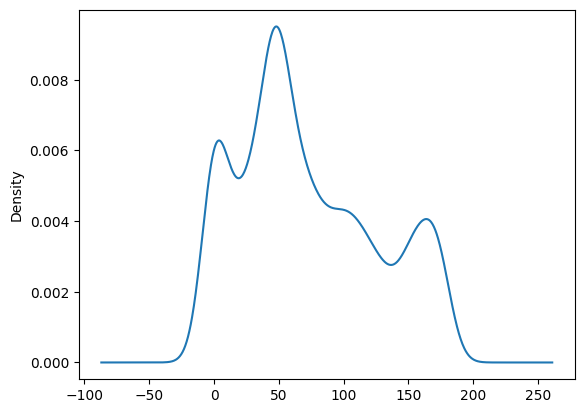

In [115]:
df["luxury_score"].plot(kind="kde")

<Axes: ylabel='luxury_score'>

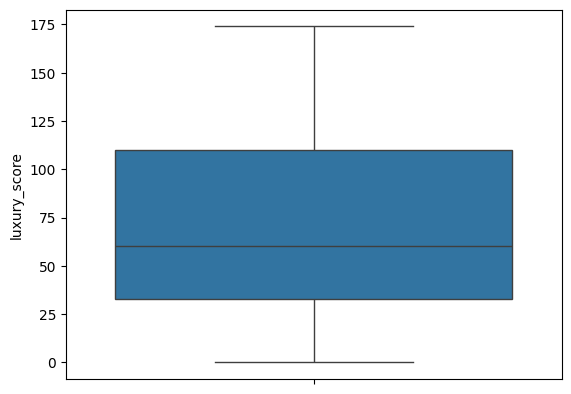

In [116]:
sns.boxplot(df["luxury_score"])

In [117]:
df["price_per_sqft"]=round(df["price"]*10000000/df["area"])

<Axes: xlabel='price_per_sqft', ylabel='Density'>

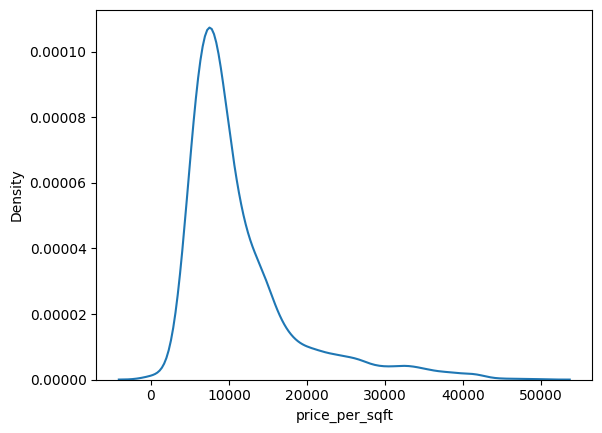

In [118]:
sns.kdeplot(df["price_per_sqft"])

<Axes: ylabel='price_per_sqft'>

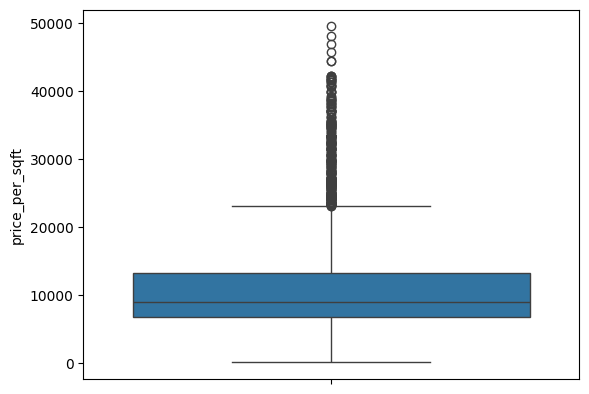

In [119]:
sns.boxplot(df["price_per_sqft"])

In [120]:
df[df["price_per_sqft"]>42000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
711,house,independent,sector 26,20.0,44444.0,4500.0,Plot area 500(418.06 sq.m.),5.0,7.0,3+,3.0,West,Relatively New,NaN,4500.0,NaN,0.0,1.0,0.0,1.0,0.0,2.0,97.0
901,house,independent,sector 28,12.0,42194.0,2844.0,Plot area 316(264.22 sq.m.),4.0,5.0,3+,4.0,East,Relatively New,NaN,2844.0,NaN,0.0,1.0,1.0,1.0,0.0,1.0,60.0
1090,house,independent,sector 105,9.9,49500.0,2000.0,Built Up area: 2000 (185.81 sq.m.)Carpet area:...,2.0,2.0,2,3.0,North,Undefined,NaN,2000.0,1800.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1509,house,independent,sector 55,5.0,44444.0,1125.0,Plot area 125(104.52 sq.m.)Built Up area: 115 ...,9.0,9.0,3+,5.0,East,New Property,NaN,115.0,100.000000,0.0,0.0,0.0,0.0,1.0,1.0,44.0
1526,house,dlf city plots,sector 26,19.0,42054.0,4518.0,Plot area 502(419.74 sq.m.),6.0,6.0,3,2.0,East,Relatively New,NaN,4518.0,NaN,1.0,1.0,0.0,0.0,0.0,1.0,121.0
2040,house,independent,sector 43,9.5,42222.0,2250.0,Plot area 302(252.51 sq.m.)Built Up area: 300 ...,5.0,5.0,3+,2.0,North-East,Relatively New,NaN,300.0,250.000000,0.0,1.0,0.0,1.0,0.0,1.0,88.0
2056,flat,breez global hill view,sohna road,2.6,46931.0,554.0,Carpet area: 554.16 (51.48 sq.m.),2.0,2.0,2,6.0,NaN,New Property,NaN,NaN,554.125572,0.0,0.0,0.0,0.0,0.0,0.0,42.0
2130,house,independent,sector 26,19.0,42222.0,4500.0,Plot area 500(418.06 sq.m.),6.0,8.0,3+,3.0,East,Moderately Old,NaN,4500.0,NaN,1.0,1.0,1.0,1.0,0.0,1.0,103.0
3054,house,sushant lok 1 builder floors,sector 43,13.0,48148.0,2700.0,Plot area 300(250.84 sq.m.),3.0,3.0,3+,4.0,North,New Property,NaN,2700.0,NaN,0.0,0.0,0.0,1.0,0.0,1.0,7.0
3108,house,independent,sector 25,13.0,45710.0,2844.0,Plot area 316(264.22 sq.m.),6.0,8.0,3+,NaN,NaN,Relatively New,NaN,2844.0,NaN,1.0,1.0,1.0,1.0,0.0,2.0,0.0


In [121]:
x=df[df["price_per_sqft"]<=20000]

In [122]:
df["area_room_ratio"]=(x["area"]/x["bedRoom"])

In [123]:
df[df["area"]/df["bedRoom"]<250]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
9,house,independent,sector 105,1.20,10118.0,1186.0,Plot area 1185.51(110.14 sq.m.),6.0,2.0,1,2.0,North-West,Old Property,NaN,1185.51,NaN,0.0,0.0,0.0,0.0,0.0,0.0,9.0,197.666667
15,house,independent,sector 12,1.20,14184.0,846.0,Plot area 846(78.6 sq.m.)Built Up area: 846 sq...,4.0,4.0,2,2.0,North,Relatively New,NaN,846.00,NaN,0.0,0.0,0.0,1.0,0.0,1.0,7.0,211.500000
37,house,independent,sector 104,0.45,12162.0,370.0,Plot area 370(34.37 sq.m.)Carpet area: 1500 sq...,4.0,4.0,2,4.0,North,Moderately Old,NaN,NaN,1500.000000,0.0,0.0,0.0,0.0,0.0,1.0,7.0,92.500000
74,house,independent,sector 25,7.60,38756.0,1961.0,Plot area 215(179.77 sq.m.),9.0,9.0,3,4.0,East,Relatively New,NaN,1935.00,NaN,1.0,0.0,1.0,1.0,0.0,1.0,84.0,NaN
93,house,independent,sector 105,1.10,12222.0,900.0,Carpet area: 900 (83.61 sq.m.),6.0,4.0,1,1.0,South-West,Undefined,NaN,NaN,900.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,150.000000
97,flat,pivotal devaan,sector 84,0.34,7039.0,483.0,Carpet area: 483 (44.87 sq.m.),2.0,2.0,1,1.0,East,Relatively New,NaN,NaN,483.000000,0.0,0.0,1.0,0.0,0.0,1.0,84.0,241.500000
99,house,independent,sector 4,1.10,11111.0,990.0,Built Up area: 990 (91.97 sq.m.),6.0,4.0,1,2.0,North,Undefined,NaN,990.00,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,165.000000
128,flat,breez global heights 88a,sector 88a,0.50,8375.0,597.0,Carpet area: 597 (55.46 sq.m.),3.0,2.0,2,2.0,NaN,Under Construction,NaN,NaN,597.000000,0.0,0.0,0.0,0.0,0.0,0.0,15.0,199.000000
140,house,independent,sector 28,0.70,8102.0,864.0,Plot area 864(80.27 sq.m.),4.0,2.0,0,2.0,North,Old Property,NaN,864.00,NaN,0.0,0.0,0.0,0.0,0.0,0.0,7.0,216.000000
155,house,independent,sector 51,2.25,25000.0,900.0,Plot area 100(83.61 sq.m.),6.0,3.0,3+,3.0,North-West,Relatively New,NaN,900.00,NaN,0.0,0.0,0.0,0.0,0.0,0.0,54.0,NaN


In [124]:
df=df[df["area_room_ratio"]>100 ]

In [125]:
outlier_df=df[(df["area_room_ratio"]<250)& (df['bedRoom']>3)]

In [126]:
outlier_df["bedRoom"]=round(outlier_df["bedRoom"]/outlier_df['floorNum'])

/tmp/ipykernel_4739/3984258184.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outlier_df["bedRoom"]=round(outlier_df["bedRoom"]/outlier_df['floorNum'])


In [127]:
df.update(outlier_df)

In [128]:
 df["area_room_ratio"]=df["area"]/df["bedRoom"]

In [130]:
df=df[~(df["area_room_ratio"]<250)& (df['bedRoom']>4)]

In [131]:
df.shape

(119, 24)